Dataset Shape: (499, 7)
   Year  Month  Day Time of Tweet  \
0  2018      8   18       morning   
1  2018      8   18          noon   
2  2017      8   18         night   
3  2022      6    8       morning   
4  2022      6    8          noon   

                                                text sentiment     Platform  
0              What a great day!!! Looks like dream.  positive    Twitter    
1     I feel sorry, I miss you here in the sea beach  positive    Facebook   
2                                     Don't angry me  negative     Facebook  
3  We attend in the class just for listening teac...  negative    Facebook   
4                  Those who want to go, let them go  negative   Instagram   
Model Accuracy: 0.64


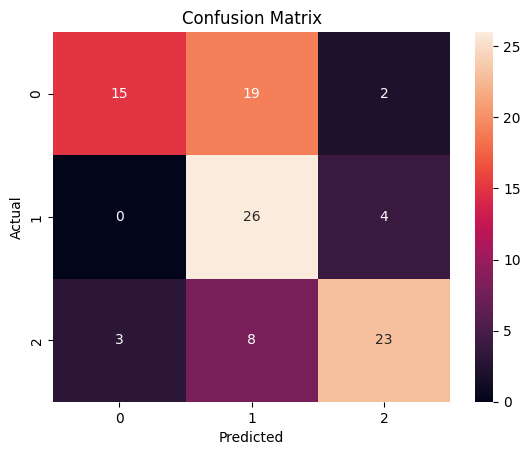

              precision    recall  f1-score   support

    negative       0.83      0.42      0.56        36
     neutral       0.49      0.87      0.63        30
    positive       0.79      0.68      0.73        34

    accuracy                           0.64       100
   macro avg       0.71      0.65      0.64       100
weighted avg       0.72      0.64      0.64       100



In [3]:


import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("sentiment_analysis.csv")

print("Dataset Shape:", df.shape)
print(df.head())

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)     # remove links
    text = re.sub(r'[^a-zA-Z ]', '', text)  # remove special characters
    return text

df["clean_text"] = df["text"].apply(clean_text)


X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


model = LogisticRegression()
model.fit(X_train_tfidf, y_train)


predictions = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", accuracy)

cm = confusion_matrix(y_test, predictions)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, predictions))